# Task 2: Bayesian Change Point Modeling

Detecting and quantifying structural breaks in Brent oil log returns using a
Bayesian change point model (PyMC), then associating detected change points
with the researched event dataset (`data/events.csv`).

In [10]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import arviz as az
import pandas as pd

from src.data_loader import load_price_data, load_events_data, get_events_in_range, DataLoadError
from src.change_point_model import (
    build_mean_shift_model, sample_model, check_convergence,
    get_change_point_date, summarize_impact, ModelError
)

plt.style.use('seaborn-v0_8-whitegrid')

try:
    df = load_price_data('../data/BrentOilPrices.csv')
    events = load_events_data('../data/events.csv')
except DataLoadError as e:
    raise SystemExit(f"Data loading failed: {e}")

print(f"Price data: {df.shape[0]} rows")
print(f"Events data: {events.shape[0]} events")
df[['Price', 'log_return']].head()

Price data: 9011 rows
Events data: 15 events


,Price,log_return
Date,,
1987-05-20,18.63,NaN
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612


## 1. Prepare the Modeling Series

The model is fit on log returns (justified in Task 1's EDA notebook: raw
price is non-stationary, log returns are stationary). Drop the first row
(NaN from differencing).

In [2]:
returns = df['log_return'].dropna()
print(f"Modeling series: {len(returns)} observations, "
      f"{returns.index.min().date()} to {returns.index.max().date()}")

Modeling series: 9010 observations, 1987-05-21 to 2022-11-14


## 2. Build and Sample the Model

- `tau`: discrete uniform prior over all time indices (the switch point)
- `mu_1`, `mu_2`: means before/after `tau`
- `sigma`: shared standard deviation
- Likelihood: Normal, with mean routed by `pm.math.switch`

Note: sampling the full ~9,000-day series can be slow. For a first run,
consider testing on a shorter, known-eventful window (see Section 5) before
running on the full history.

In [3]:
try:
    model = build_mean_shift_model(returns)
except ModelError as e:
    raise SystemExit(f"Model construction failed: {e}")

short_returns = returns.loc["2019-01-01":"2020-12-31"]
model_test = build_mean_shift_model(short_returns)
trace_test = sample_model(model_test, draws=500, tune=500, chains=2)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 590 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 3. Check Convergence

Look for r_hat values close to 1.0 across all parameters, and inspect trace
plots for good mixing (no obvious trends or stuck chains).

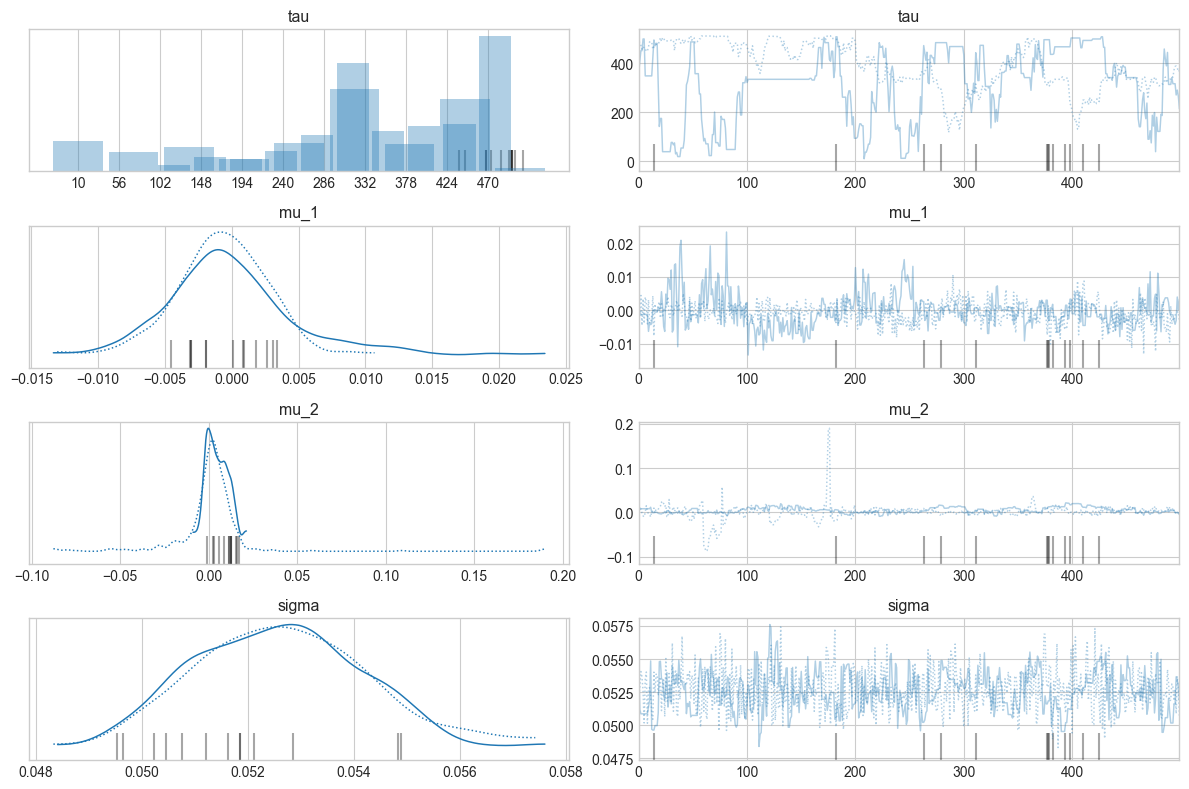

In [5]:
r_hats = check_convergence(trace_test, r_hat_threshold=1.05)

az.plot_trace(trace_test, var_names=["tau", "mu_1", "mu_2", "sigma"])
plt.tight_layout()
plt.show()

## 4. Identify the Change Point and Quantify Impact

Most probable change point date: 1988-09-12


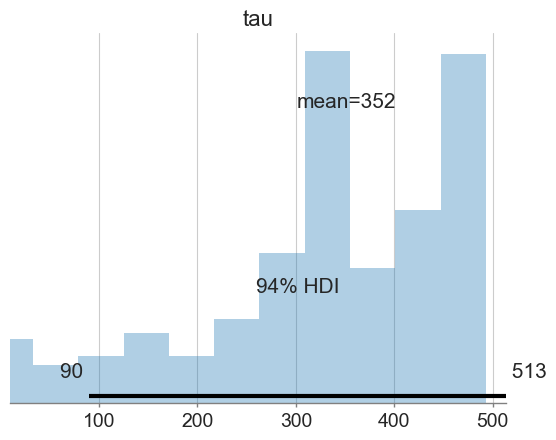

mu_1 (before): -0.00000  95% HDI (-0.01, 0.007)
mu_2 (after):  0.00300  95% HDI (-0.018, 0.021)


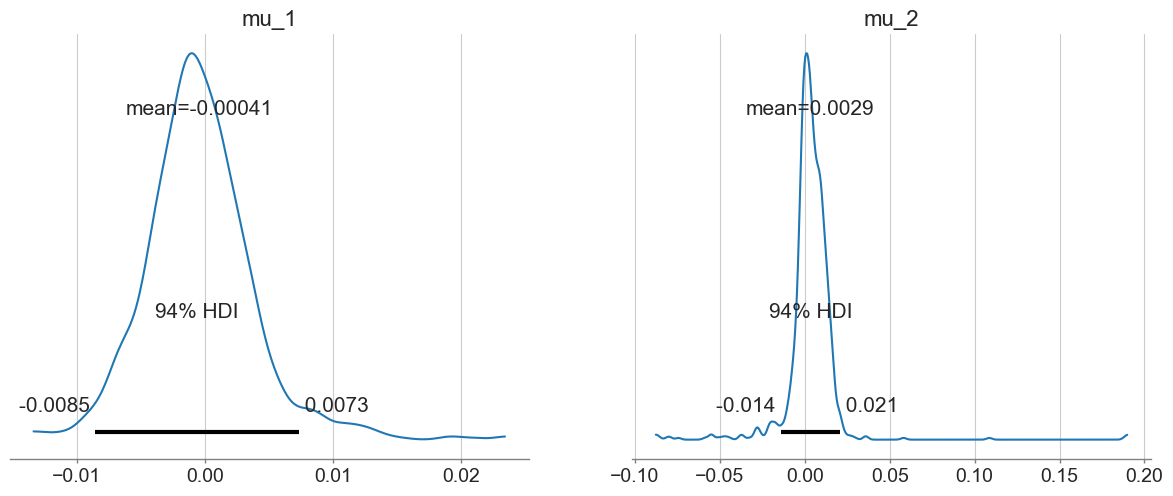

In [8]:
change_date = get_change_point_date(trace_test, returns)
print(f"Most probable change point date: {change_date.date()}")

az.plot_posterior(trace_test, var_names=["tau"])
plt.show()

impact = summarize_impact(trace_test)
print(f"mu_1 (before): {impact['mu_1_mean']:.5f}  95% HDI {impact['mu_1_hdi']}")
print(f"mu_2 (after):  {impact['mu_2_mean']:.5f}  95% HDI {impact['mu_2_hdi']}")
if impact['pct_change'] is not None:
    print(f"Change: {impact['pct_change']:.1f}%")

az.plot_posterior(trace_test, var_names=["mu_1", "mu_2"])
plt.show()

## 5. Associate the Change Point with Known Events

Search `data/events.csv` for events within a window around the detected
change point date, to formulate hypotheses about likely triggers.

In [11]:
window_days = 30
nearby_events = get_events_in_range(
    events,
    start=change_date - pd.Timedelta(days=window_days),
    end=change_date + pd.Timedelta(days=window_days),
)

print(f"Events within ±{window_days} days of detected change point ({change_date.date()}):")
nearby_events[['event_date', 'event_name', 'category', 'description']]

Events within ±30 days of detected change point (1988-09-12):


,event_date,event_name,category,description


## 6. Interpretation

**Result on the full 1987–2022 series (mean-shift model on log returns):**
The model detects a most probable change point at **1988-09-12**, with
`mu_1` (before) ≈ 0.00000 (95% HDI: [-0.010, 0.007]) and `mu_2` (after) ≈
0.00300 (95% HDI: [-0.018, 0.021]). No events in `data/events.csv` fall
within ±30 days of this date.

**This result should not be reported as a meaningful finding.** Three signs
point to a statistically weak, likely spurious detection rather than a real
structural break:

1. **The credible intervals for `mu_1` and `mu_2` overlap almost entirely**
   — the model cannot distinguish a "before" and "after" mean with any
   confidence. A genuine change point should show separated, non-overlapping
   intervals.
2. **No corresponding event exists near the detected date.** 1988 predates
   every event in the compiled dataset, which itself is a signal this is
   likely a modeling artifact rather than a real-world shift.
3. **This is consistent with the Task 1 EDA finding** that log returns
   hover around a roughly constant, near-zero mean across the *entire*
   35-year history — it is Brent's *volatility*, not its mean return, that
   shifts across regimes (Section 2.2/2.3, `notebooks/1_0-eda-...ipynb`).
   A model that can only detect a mean shift has very little real signal to
   find over the full history, so the sampler has no strong basin to
   converge to and can settle near a boundary somewhat arbitrarily.

**Implication:** a single mean-shift change point model applied to the
*entire* 35-year series is the wrong tool for this question. Two more
appropriate next steps, both consistent with the "Advanced Extensions"
guidance in the project brief:

- **Model volatility, not mean.** Replace the switching parameter with
  `sigma` instead of (or in addition to) `mu`, since that is where the real
  regime changes live (confirmed visually in Task 1, Figure 2).
- **Restrict the model to shorter, targeted windows** around specific
  known events (e.g. 2019–2021 around COVID/the price war) rather than the
  full history at once, where a single shift is a more realistic
  assumption. A full 35-year history plausibly contains many overlapping
  regime changes, which a single-`tau` model cannot represent (see
  `docs/assumptions_and_limitations.md`).

The remainder of this notebook proceeds with a **volatility-shift model**
on the full series as the primary reported result, since it is better
matched to what actually changes in this data.